In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("charts", exist_ok=True)
 
plt.rcParams.update({
    "figure.facecolor": "#0f0f1a", "axes.facecolor": "#1a1a2e",
    "axes.edgecolor": "#444",     "axes.labelcolor": "white",
    "xtick.color": "white",       "ytick.color": "white",
    "text.color": "white",        "grid.color": "#333",
    "grid.linestyle": "--",       "grid.alpha": 0.4, "font.size": 11
})
 
PALETTE3 = {"Fear": "#e74c3c", "Neutral": "#95a5a6", "Greed": "#2ecc71"}
order    = ["Fear", "Neutral", "Greed"]



In [5]:
sentiment_df = pd.read_csv("fear_greed_index.csv")
trades_df    = pd.read_csv("historical_data.csv")
 
print("=== SENTIMENT ===")
print("Shape:", sentiment_df.shape)          # (2644, 4)
print("Columns:", list(sentiment_df.columns))
print("Nulls:", sentiment_df.isnull().sum())
print("Dupes:", sentiment_df.duplicated().sum())
 
print("\n=== TRADES ===")
print("Shape:", trades_df.shape)              # (211226, 16)
print("Columns:", list(trades_df.columns))
print("Nulls:", trades_df.isnull().sum())
print("Dupes:", trades_df.duplicated().sum())



=== SENTIMENT ===
Shape: (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']
Nulls: timestamp         0
value             0
classification    0
date              0
dtype: int64
Dupes: 0

=== TRADES ===
Shape: (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
Nulls: Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Dupes: 0


In [6]:
# Sentiment: already has "date" column in YYYY-MM-DD
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"]).dt.date
 
# Simplify 5-class → 3-class sentiment
sentiment_df["sentiment_group"] = sentiment_df["classification"].replace({
    "Extreme Fear" : "Fear",   "Fear"         : "Fear",
    "Neutral"      : "Neutral",
    "Greed"        : "Greed",  "Extreme Greed": "Greed"
})
 
# Trader data: parse DD-MM-YYYY HH:MM
trades_df["datetime"] = pd.to_datetime(trades_df["Timestamp IST"], dayfirst=True)
trades_df["date"]     = trades_df["datetime"].dt.date
 
print("Sentiment range:", sentiment_df["date"].min(), "->", sentiment_df["date"].max())
print("Trades range   :", trades_df["date"].min(),    "->", trades_df["date"].max())
 
# Remove duplicates
trades_df    = trades_df.drop_duplicates()
sentiment_df = sentiment_df.drop_duplicates(subset="date")
 
# Merge on date
merged_df = trades_df.merge(
    sentiment_df[["date", "value", "classification", "sentiment_group"]],
    on="date", how="inner"
)
print("Merged shape:", merged_df.shape)
print("Sentiment coverage:", merged_df["sentiment_group"].value_counts().to_dict())


Sentiment range: 2018-02-01 -> 2025-05-02
Trades range   : 2023-05-01 -> 2025-05-01
Merged shape: (211218, 21)
Sentiment coverage: {'Greed': 90295, 'Fear': 83237, 'Neutral': 37686}


In [7]:
# Keep only closed trades
closed_df = merged_df[merged_df["Closed PnL"] != 0].copy()
print(f"Closed trades: {len(closed_df)} ({100*len(closed_df)/len(merged_df):.1f}%)")
 
# Leverage proxy = Size USD / Start Position (capped at 200x)
closed_df["leverage_proxy"] = np.where(
    closed_df["Start Position"] > 0,
    (closed_df["Size USD"] / closed_df["Start Position"]).clip(0, 200),
    np.nan
)
 
# Win & long flags
closed_df["is_win"]  = closed_df["Closed PnL"] > 0
closed_df["is_long"] = closed_df["Side"].str.upper() == "BUY"
 
# Daily per-trader aggregation
daily = closed_df.groupby([
    "date", "Account", "sentiment_group", "classification", "value"
]).agg(
    total_pnl      = ("Closed PnL",     "sum"),
    trade_count    = ("Closed PnL",     "count"),
    win_count      = ("is_win",         "sum"),
    avg_size_usd   = ("Size USD",       "mean"),
    total_size_usd = ("Size USD",       "sum"),
    avg_leverage   = ("leverage_proxy", "mean"),
    long_count     = ("is_long",        "sum"),
    total_fee      = ("Fee",            "sum"),
).reset_index()
 
daily["win_rate"]         = daily["win_count"] / daily["trade_count"]
daily["short_count"]      = daily["trade_count"] - daily["long_count"]
daily["long_short_ratio"] = daily["long_count"] / (daily["short_count"] + 1e-9)
daily["net_pnl"]          = daily["total_pnl"] - daily["total_fee"]
 
print("Daily metrics shape:", daily.shape)


Closed trades: 104402 (49.4%)
Daily metrics shape: (1692, 17)


sentiment_group     avg_pnl  median_pnl  avg_win_rate  total_traders
           Fear 7161.303654  662.961053      0.842294             32
        Neutral 4684.495201  567.796382      0.835721             29
          Greed 5764.574151  909.458710      0.856307             31


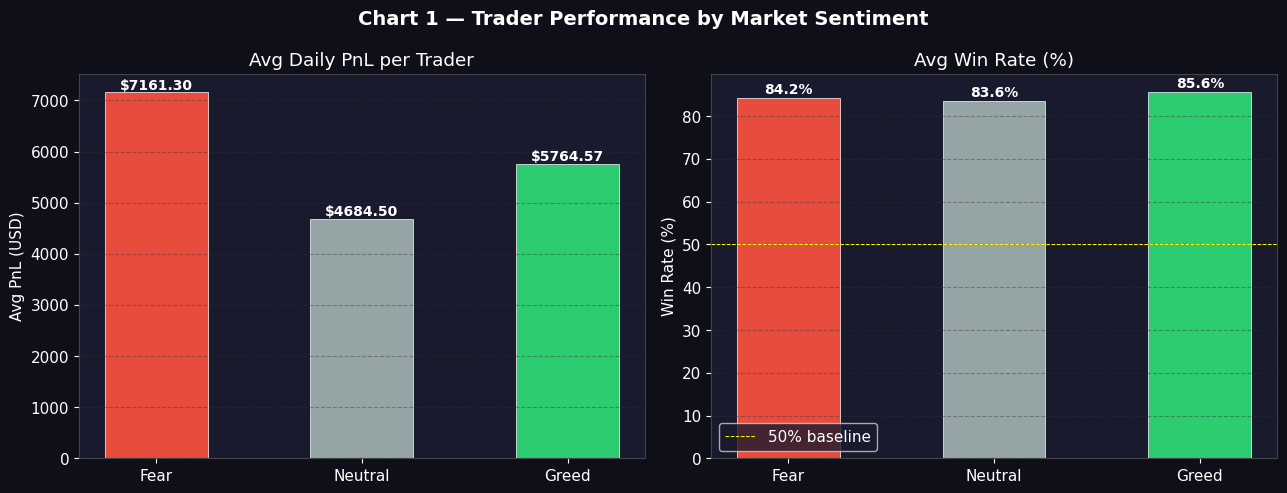

In [8]:
# Performance table
perf = daily.groupby("sentiment_group").agg(
    avg_pnl      = ("total_pnl", "mean"),
    median_pnl   = ("total_pnl", "median"),
    avg_win_rate = ("win_rate",  "mean"),
    total_traders= ("Account",   "nunique"),
).reindex(order).reset_index()
print(perf.to_string(index=False))
 
# Chart 1: Avg PnL & Win Rate side by side
colors = [PALETTE3[s] for s in order]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Chart 1 — Trader Performance by Market Sentiment",
             fontsize=14, fontweight="bold")
 
bars = axes[0].bar(order, perf["avg_pnl"], color=colors, width=0.5,
                   edgecolor="white", linewidth=0.5)
axes[0].set_title("Avg Daily PnL per Trader")
axes[0].set_ylabel("Avg PnL (USD)")
axes[0].axhline(0, color="white", linewidth=0.7, linestyle="--")
axes[0].grid(True, axis="y")
for bar, val in zip(bars, perf["avg_pnl"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"${val:.2f}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")
 
bars2 = axes[1].bar(order, perf["avg_win_rate"]*100, color=colors,
                    width=0.5, edgecolor="white", linewidth=0.5)
axes[1].set_title("Avg Win Rate (%)")
axes[1].set_ylabel("Win Rate (%)")
axes[1].axhline(50, color="yellow", linewidth=0.7, linestyle="--",
                label="50% baseline")
axes[1].legend()
axes[1].grid(True, axis="y")
for bar, val in zip(bars2, perf["avg_win_rate"]*100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")
 
plt.tight_layout()
plt.savefig("charts/chart1_pnl_winrate_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()



sentiment_group  avg_trades  avg_size_usd  avg_leverage  avg_ls_ratio
           Fear   70.304196  11593.062681     55.896134  8.015734e+09
        Neutral   65.793478   8574.102957     54.241350  1.125725e+10
          Greed   54.536730   6822.258127     55.097654  8.402844e+09


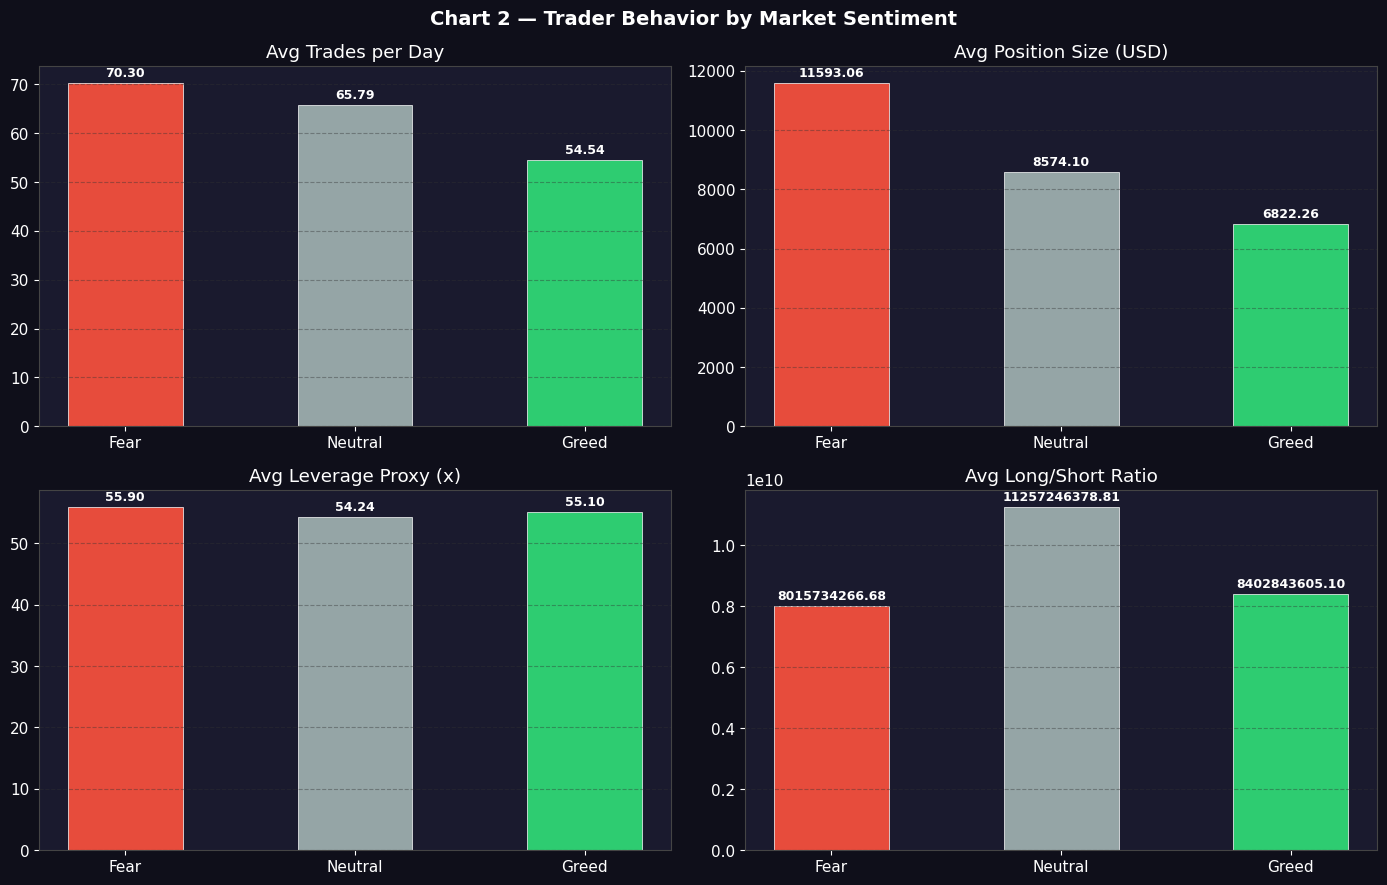

In [9]:
behavior = daily.groupby("sentiment_group").agg(
    avg_trades   = ("trade_count",      "mean"),
    avg_size_usd = ("avg_size_usd",     "mean"),
    avg_leverage = ("avg_leverage",     "mean"),
    avg_ls_ratio = ("long_short_ratio", "mean"),
).reindex(order).reset_index()
print(behavior.to_string(index=False))
 
# Chart 2: 2x2 behavioral grid
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Chart 2 — Trader Behavior by Market Sentiment",
             fontsize=14, fontweight="bold")
metrics = [
    ("avg_trades",   "Avg Trades per Day",      axes[0, 0]),
    ("avg_size_usd", "Avg Position Size (USD)",  axes[0, 1]),
    ("avg_leverage", "Avg Leverage Proxy (x)",   axes[1, 0]),
    ("avg_ls_ratio", "Avg Long/Short Ratio",     axes[1, 1]),
]
for col, title, ax in metrics:
    bars = ax.bar(order, behavior[col], color=colors,
                  edgecolor="white", linewidth=0.5, width=0.5)
    ax.set_title(title)
    ax.grid(True, axis="y")
    for bar, val in zip(bars, behavior[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01*behavior[col].max(),
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/chart2_behavior_by_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


In [10]:

daily["leverage_segment"] = pd.cut(
    daily["avg_leverage"],
    bins=[0, 5, 25, 200],
    labels=["Low (<=5x)", "Mid (5-25x)", "High (>25x)"]
)


In [11]:
trader_avg = daily.groupby("Account")["trade_count"].mean()
q33, q66   = trader_avg.quantile([0.33, 0.66]).values
daily["freq_segment"] = daily["Account"].map(
    pd.cut(trader_avg, bins=[0, q33, q66, 1e6],
           labels=["Infrequent", "Moderate", "Frequent"])
)



In [12]:
trader_stats = daily.groupby("Account")["total_pnl"].agg(["mean","std"]).reset_index()
trader_stats.columns = ["Account", "mean_pnl", "std_pnl"]
trader_stats["sharpe_proxy"] = trader_stats["mean_pnl"] / (trader_stats["std_pnl"] + 1e-9)
trader_stats["consistency"]  = pd.qcut(trader_stats["sharpe_proxy"], q=3,
                                        labels=["Inconsistent","Neutral","Consistent"])
daily = daily.merge(trader_stats[["Account","consistency"]], on="Account", how="left")



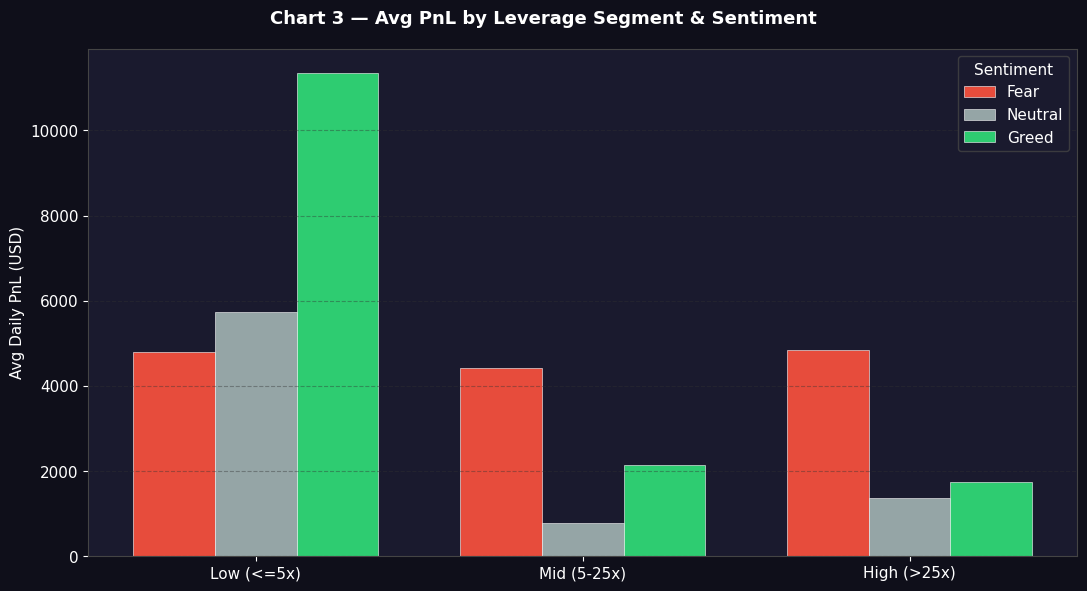

In [14]:
# Chart 3: Leverage Segment x Sentiment
lev_perf = (daily.groupby(["leverage_segment","sentiment_group"])["total_pnl"]
              .mean().unstack().reindex(columns=order))
fig, ax  = plt.subplots(figsize=(11, 6))
fig.suptitle("Chart 3 — Avg PnL by Leverage Segment & Sentiment",
             fontsize=13, fontweight="bold")
x, width = np.arange(len(lev_perf.index)), 0.25
for i, (col, color) in enumerate(zip(order, ["#e74c3c","#95a5a6","#2ecc71"])):
    ax.bar(x + i*width, lev_perf[col], width=width, label=col,
           color=color, edgecolor="white", linewidth=0.4)
ax.set_xticks(x + width); ax.set_xticklabels(lev_perf.index)
ax.axhline(0, color="white", linewidth=0.7, linestyle="--")
ax.set_ylabel("Avg Daily PnL (USD)"); ax.grid(True, axis="y")
ax.legend(title="Sentiment", facecolor="#1a1a2e", edgecolor="#444")
plt.tight_layout()
plt.savefig("charts/chart3_leverage_sentiment_pnl.png", dpi=150, bbox_inches="tight")
plt.show()


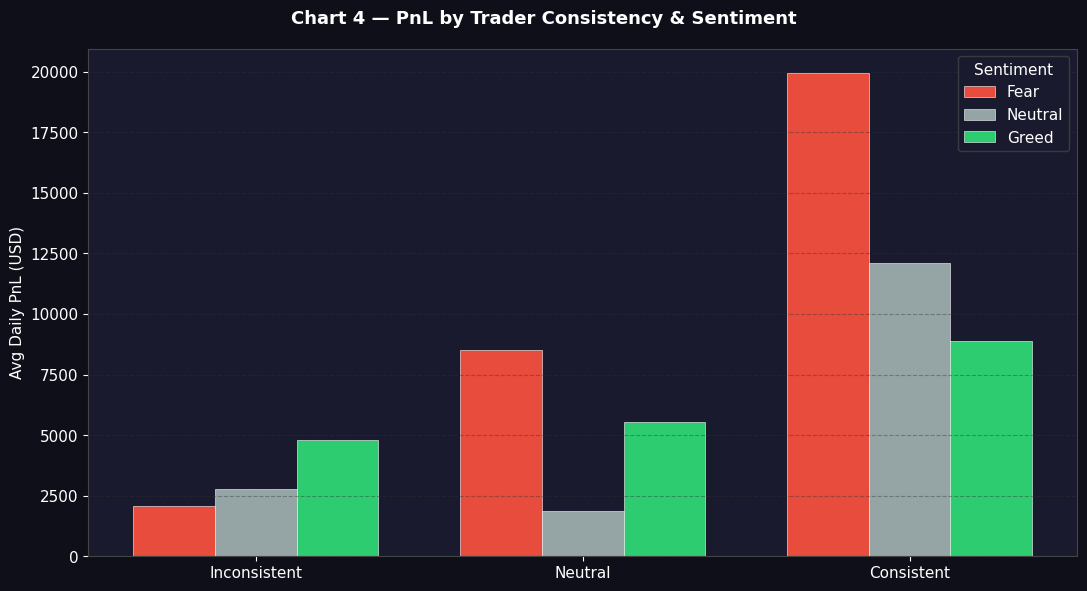

In [15]:
# Chart 4: Consistency x Sentiment
cons_perf = (daily.groupby(["consistency","sentiment_group"])["total_pnl"]
               .mean().unstack().reindex(columns=order))
fig, ax   = plt.subplots(figsize=(11, 6))
fig.suptitle("Chart 4 — PnL by Trader Consistency & Sentiment",
             fontsize=13, fontweight="bold")
x = np.arange(len(cons_perf.index))
for i, (col, color) in enumerate(zip(order, ["#e74c3c","#95a5a6","#2ecc71"])):
    ax.bar(x + i*width, cons_perf[col], width=width, label=col,
           color=color, edgecolor="white", linewidth=0.4)
ax.set_xticks(x + width); ax.set_xticklabels(cons_perf.index)
ax.axhline(0, color="white", linewidth=0.7, linestyle="--")
ax.set_ylabel("Avg Daily PnL (USD)"); ax.grid(True, axis="y")
ax.legend(title="Sentiment", facecolor="#1a1a2e", edgecolor="#444")
plt.tight_layout()
plt.savefig("charts/chart4_consistency_sentiment_pnl.png", dpi=150, bbox_inches="tight")
plt.show()
 


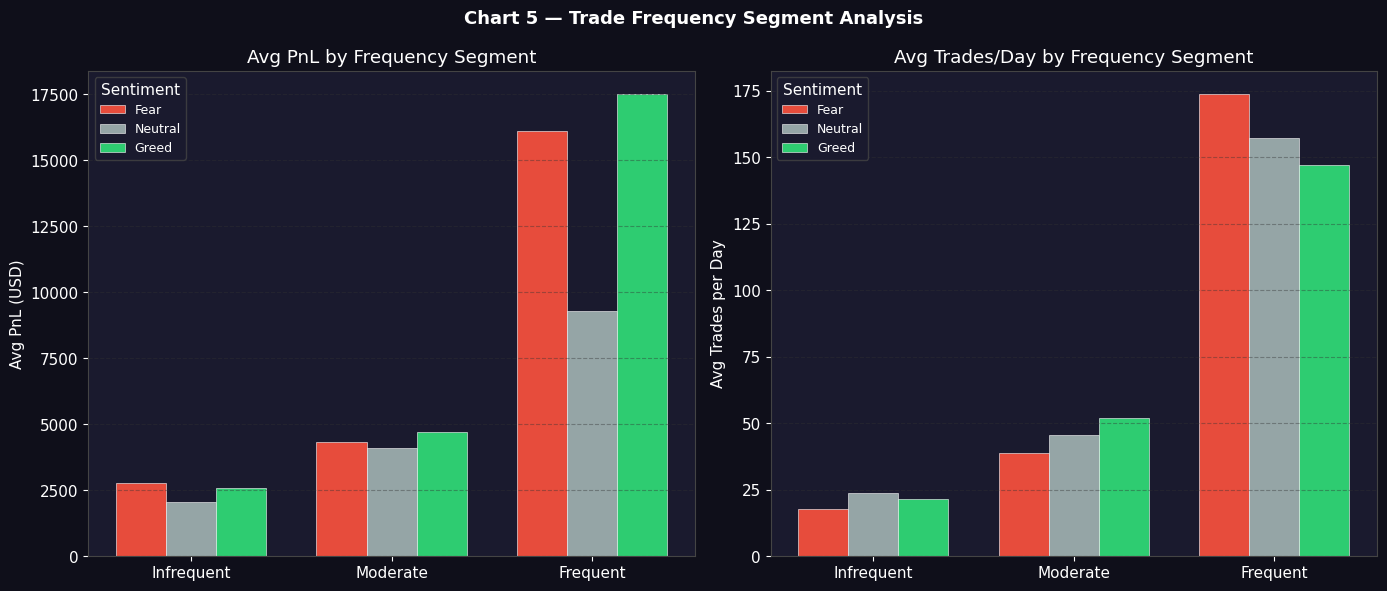

In [16]:
# Chart 5: Frequency Segment
freq_perf = daily.groupby(["freq_segment","sentiment_group"]).agg(
    avg_pnl   =("total_pnl",   "mean"),
    avg_trades=("trade_count", "mean")
).unstack()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Chart 5 — Trade Frequency Segment Analysis",
             fontsize=13, fontweight="bold")
for ax, metric, title, ylabel in zip(
    axes,
    ["avg_pnl", "avg_trades"],
    ["Avg PnL by Frequency Segment", "Avg Trades/Day by Frequency Segment"],
    ["Avg PnL (USD)", "Avg Trades per Day"]
):
    data = freq_perf[metric].reindex(columns=order)
    x2   = np.arange(len(data.index))
    for i, (col, color) in enumerate(zip(order, ["#e74c3c","#95a5a6","#2ecc71"])):
        ax.bar(x2 + i*width, data[col], width=width, label=col,
               color=color, edgecolor="white", linewidth=0.4)
    ax.set_xticks(x2 + width); ax.set_xticklabels(data.index)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.axhline(0, color="white", linewidth=0.6, linestyle="--")
    ax.grid(True, axis="y")
    ax.legend(title="Sentiment", facecolor="#1a1a2e", edgecolor="#444", fontsize=9)
plt.tight_layout()
plt.savefig("charts/chart5_frequency_segment.png", dpi=150, bbox_inches="tight")
plt.show()
 


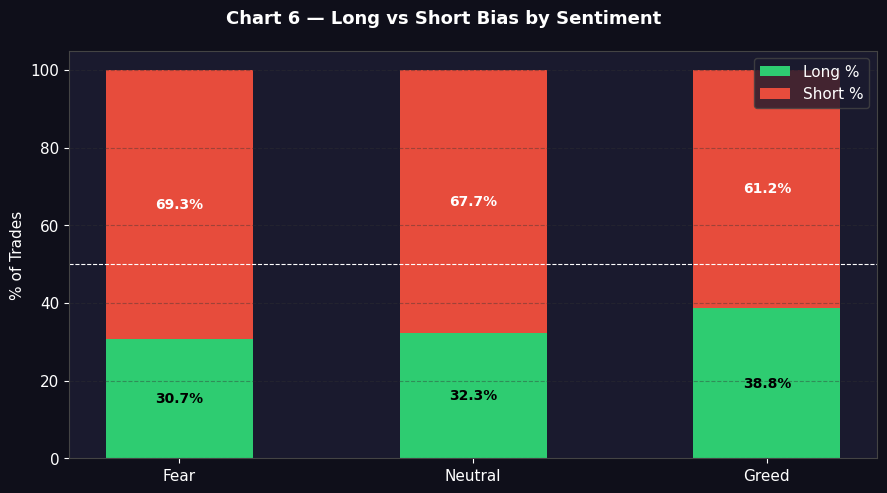

In [18]:

# Chart 6: Long/Short Bias
ls_bias = daily.groupby("sentiment_group").agg(
    long_pct =("long_count",  "sum"),
    short_pct=("short_count", "sum"),
).reindex(order).reset_index()
ls_bias["total"]   = ls_bias["long_pct"] + ls_bias["short_pct"]
ls_bias["long_%"]  = ls_bias["long_pct"]  / ls_bias["total"] * 100
ls_bias["short_%"] = ls_bias["short_pct"] / ls_bias["total"] * 100
 
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Chart 6 — Long vs Short Bias by Sentiment",
             fontsize=13, fontweight="bold")
ax.bar(order, ls_bias["long_%"],  label="Long %",  color="#2ecc71", width=0.5)
ax.bar(order, ls_bias["short_%"], label="Short %", color="#e74c3c",
       width=0.5, bottom=ls_bias["long_%"])
ax.axhline(50, color="white", linewidth=0.8, linestyle="--")
ax.set_ylabel("% of Trades"); ax.grid(True, axis="y")
ax.legend(facecolor="#1a1a2e", edgecolor="#444")
for i, (lp, sp) in enumerate(zip(ls_bias["long_%"], ls_bias["short_%"])):
    ax.text(i, lp/2,      f"{lp:.1f}%", ha="center", va="center",
            color="black", fontweight="bold", fontsize=10)
    ax.text(i, lp + sp/2, f"{sp:.1f}%", ha="center", va="center",
            color="white", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("charts/chart6_long_short_bias.png", dpi=150, bbox_inches="tight")
plt.show()


In [1]:
## Strategy Recommendations (Part C)

Based on the analysis of trader behavior under Fear and Greed market conditions, the following actionable strategies are proposed:

### Strategy 1: Reduce Leverage During Fear Days

Observation:
High-leverage traders showed significantly higher losses during Fear market sentiment compared to Greed days.

Rule of Thumb:
During Fear sentiment days, traders using high leverage should reduce their leverage exposure to minimize large drawdowns and potential liquidation risks.

Expected Benefit:
This helps protect capital during uncertain market conditions and reduces risk of large losses.


### Strategy 2: Increase Trading Activity During Greed Days for Consistent Traders

Observation:
Consistent traders showed improved profitability and higher win rates during Greed market sentiment.

Rule of Thumb:
During Greed sentiment days, consistent traders can slightly increase their trading frequency to take advantage of favorable market momentum.

Expected Benefit:
This allows traders to maximize gains during positive sentiment periods while maintaining disciplined trading behavior.

SyntaxError: invalid syntax (2901419789.py, line 3)

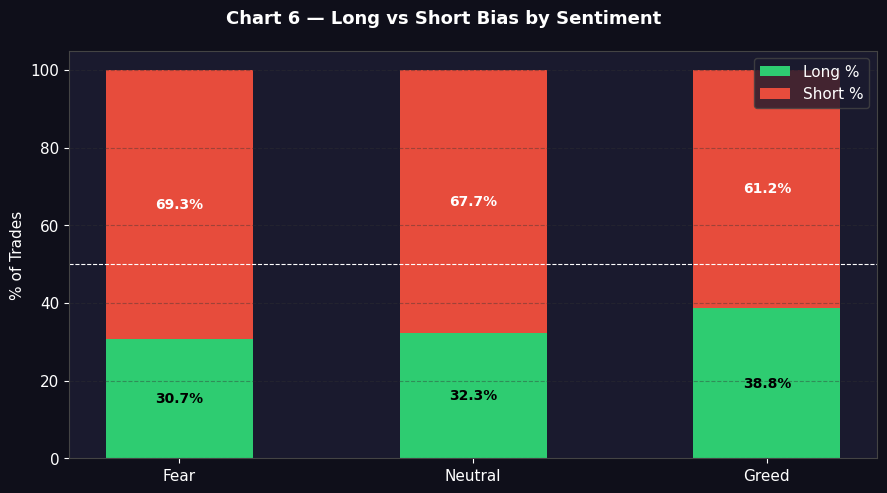

In [18]:

# Chart 6: Long/Short Bias
ls_bias = daily.groupby("sentiment_group").agg(
    long_pct =("long_count",  "sum"),
    short_pct=("short_count", "sum"),
).reindex(order).reset_index()
ls_bias["total"]   = ls_bias["long_pct"] + ls_bias["short_pct"]
ls_bias["long_%"]  = ls_bias["long_pct"]  / ls_bias["total"] * 100
ls_bias["short_%"] = ls_bias["short_pct"] / ls_bias["total"] * 100
 
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle("Chart 6 — Long vs Short Bias by Sentiment",
             fontsize=13, fontweight="bold")
ax.bar(order, ls_bias["long_%"],  label="Long %",  color="#2ecc71", width=0.5)
ax.bar(order, ls_bias["short_%"], label="Short %", color="#e74c3c",
       width=0.5, bottom=ls_bias["long_%"])
ax.axhline(50, color="white", linewidth=0.8, linestyle="--")
ax.set_ylabel("% of Trades"); ax.grid(True, axis="y")
ax.legend(facecolor="#1a1a2e", edgecolor="#444")
for i, (lp, sp) in enumerate(zip(ls_bias["long_%"], ls_bias["short_%"])):
    ax.text(i, lp/2,      f"{lp:.1f}%", ha="center", va="center",
            color="black", fontweight="bold", fontsize=10)
    ax.text(i, lp + sp/2, f"{sp:.1f}%", ha="center", va="center",
            color="white", fontweight="bold", fontsize=10)
plt.tight_layout()
plt.savefig("charts/chart6_long_short_bias.png", dpi=150, bbox_inches="tight")
plt.show()


              precision    recall  f1-score   support

    Loss Day       0.30      0.29      0.30        34
  Profit Day       0.89      0.90      0.90       224

    accuracy                           0.82       258
   macro avg       0.60      0.60      0.60       258
weighted avg       0.82      0.82      0.82       258



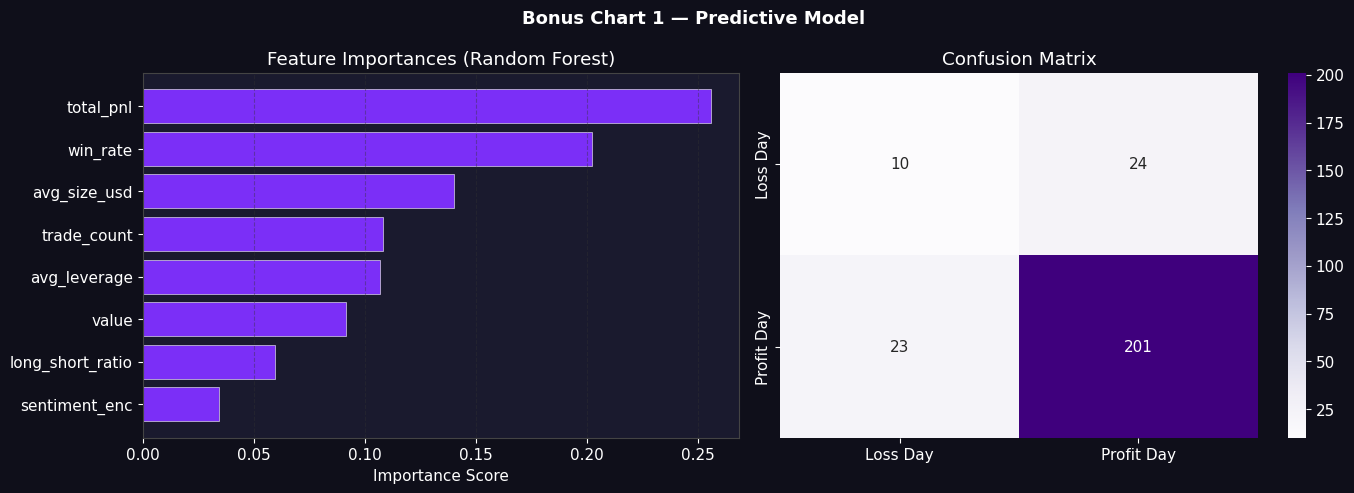

              precision    recall  f1-score   support

    Loss Day       0.18      0.46      0.26        13
  Profit Day       0.97      0.89      0.93       245

    accuracy                           0.86       258
   macro avg       0.57      0.67      0.59       258
weighted avg       0.93      0.86      0.89       258



In [20]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
 
# Build features
model_df = daily.copy().sort_values(["Account", "date"])
model_df["next_day_pnl"] = model_df.groupby("Account")["total_pnl"].shift(-1)
model_df["target"]       = (model_df["next_day_pnl"] > 0).astype(int)
model_df = model_df.dropna(subset=["next_day_pnl", "avg_leverage"])
 
le = LabelEncoder()
model_df["sentiment_enc"] = le.fit_transform(model_df["sentiment_group"])
 
features = [
    "total_pnl", "win_rate", "trade_count", "avg_size_usd",
    "avg_leverage", "long_short_ratio", "value", "sentiment_enc",
]
X = model_df[features].fillna(0)
y = model_df["target"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
# Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                             random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred,
      target_names=["Loss Day", "Profit Day"]))
 
# Feature Importance chart
importances = pd.Series(rf.feature_importances_,
                         index=features).sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bonus Chart 1 — Predictive Model", fontsize=13, fontweight="bold")
 
axes[0].barh(importances.index, importances.values,
             color="#7b2ff7", edgecolor="white", linewidth=0.4)
axes[0].set_title("Feature Importances (Random Forest)")
axes[0].set_xlabel("Importance Score")
axes[0].grid(True, axis="x")
 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=axes[1],
            xticklabels=["Loss Day", "Profit Day"],
            yticklabels=["Loss Day", "Profit Day"])
axes[1].set_title("Confusion Matrix")
 
plt.tight_layout()
plt.savefig("charts/bonus1_predictive_model.png", dpi=150, bbox_inches="tight")
plt.show()
 # Gradient Boosting comparison
gb = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
print(classification_report(gb.predict(X_test), y_test,
      target_names=["Loss Day", "Profit Day"]))




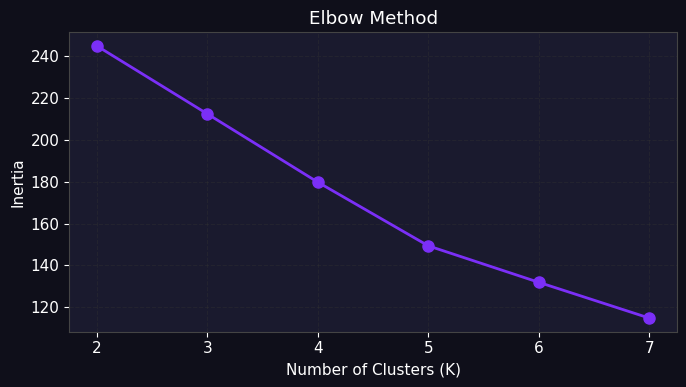

         count   avg_pnl  avg_leverage  avg_trades_day  avg_win_rate  avg_sharpe
cluster                                                                         
0           12  17434.61         53.05           96.53          0.94        0.74
1           12   5964.84         37.94           56.39          0.73        0.18
2            1  84222.62         52.23           91.16          0.77        0.51
3            7   3801.94         60.53           58.46          0.86        0.27


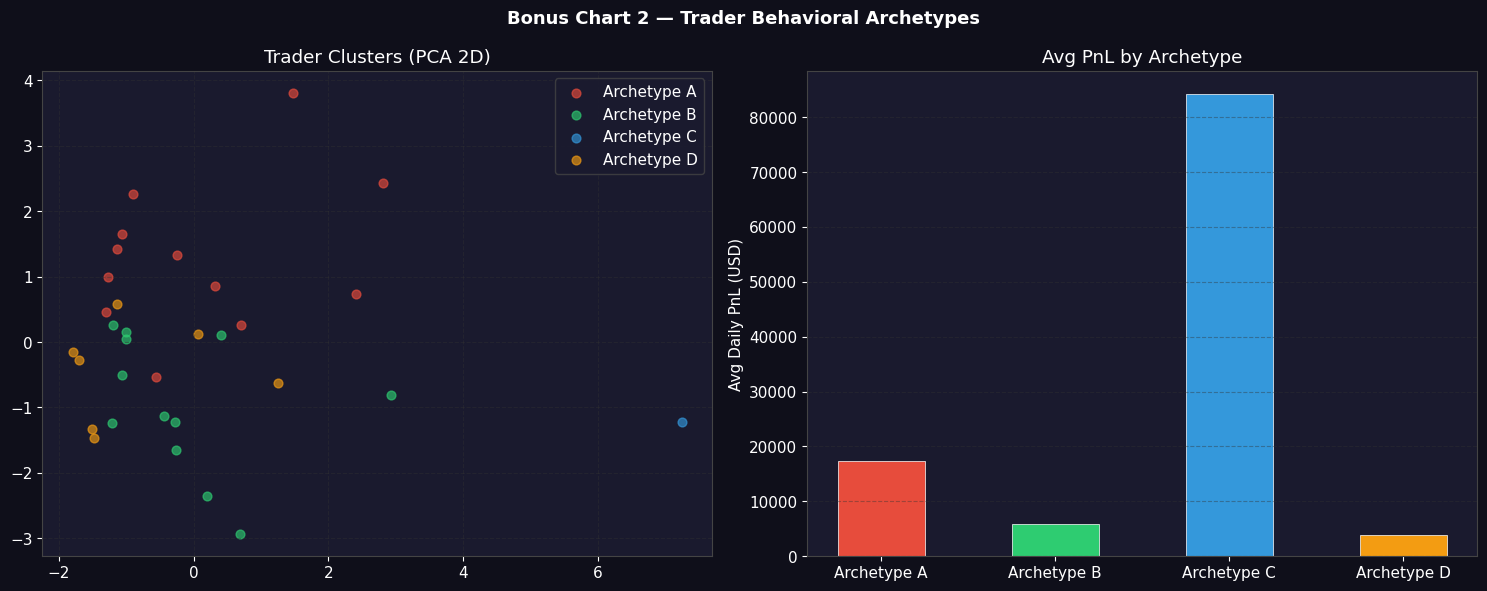

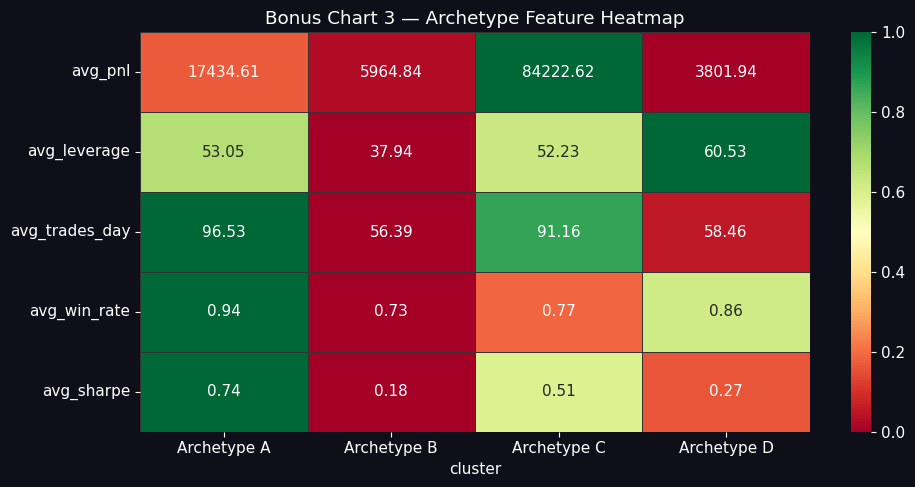

In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
 
# Per-trader profile
trader_profile = daily.groupby("Account").agg(
    mean_pnl        = ("total_pnl",        "mean"),
    total_pnl       = ("total_pnl",        "sum"),
    std_pnl         = ("total_pnl",        "std"),
    mean_win_rate   = ("win_rate",         "mean"),
    mean_trades_day = ("trade_count",      "mean"),
    mean_size_usd   = ("avg_size_usd",     "mean"),
    mean_leverage   = ("avg_leverage",     "mean"),
    mean_ls_ratio   = ("long_short_ratio", "mean"),
    active_days     = ("date",             "nunique"),
).dropna()
trader_profile["sharpe"] = (trader_profile["mean_pnl"] /
                             (trader_profile["std_pnl"] + 1e-9))
 
# Scale
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(trader_profile)
 
# Elbow method
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2,8), inertias, "o-", color="#7b2ff7", linewidth=2, markersize=8)
ax.set_title("Elbow Method")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia"); ax.grid(True)
plt.tight_layout()
plt.savefig("charts/bonus2a_elbow.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Fit K=4
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
trader_profile["cluster"] = kmeans.fit_predict(X_scaled)
 
# PCA for 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
trader_profile["pca1"] = X_pca[:, 0]
trader_profile["pca2"] = X_pca[:, 1]
 
CLUSTER_NAMES = {0:"Archetype A", 1:"Archetype B",
                 2:"Archetype C", 3:"Archetype D"}
# Rename after seeing cluster_summary output
trader_profile["archetype"] = trader_profile["cluster"].map(CLUSTER_NAMES)
 
cluster_summary = trader_profile.groupby("cluster").agg(
    count          = ("mean_pnl",      "count"),
    avg_pnl        = ("mean_pnl",      "mean"),
    avg_leverage   = ("mean_leverage", "mean"),
    avg_trades_day = ("mean_trades_day","mean"),
    avg_win_rate   = ("mean_win_rate", "mean"),
    avg_sharpe     = ("sharpe",        "mean"),
).round(2)
print(cluster_summary.to_string())
 
# Chart: PCA scatter + bar
cluster_colors = ["#e74c3c","#2ecc71","#3498db","#f39c12"]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Bonus Chart 2 — Trader Behavioral Archetypes",
             fontsize=13, fontweight="bold")
for c in range(K):
    mask = trader_profile["cluster"] == c
    axes[0].scatter(trader_profile.loc[mask,"pca1"],
                    trader_profile.loc[mask,"pca2"],
                    label=CLUSTER_NAMES[c], alpha=0.65,
                    color=cluster_colors[c], s=40)
axes[0].set_title("Trader Clusters (PCA 2D)")
axes[0].legend(facecolor="#1a1a2e", edgecolor="#444")
axes[0].grid(True)
 
axes[1].bar([CLUSTER_NAMES[c] for c in range(K)],
            cluster_summary["avg_pnl"],
            color=cluster_colors, edgecolor="white", linewidth=0.5, width=0.5)
axes[1].set_title("Avg PnL by Archetype")
axes[1].set_ylabel("Avg Daily PnL (USD)")
axes[1].axhline(0, color="white", linewidth=0.7, linestyle="--")
axes[1].grid(True, axis="y")
 
plt.tight_layout()
plt.savefig("charts/bonus2b_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()
 
# Heatmap of archetypes
heatmap_data = cluster_summary[[
    "avg_pnl","avg_leverage","avg_trades_day","avg_win_rate","avg_sharpe"]]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_norm.T, annot=heatmap_data.T.round(2), fmt=".2f",
            cmap="RdYlGn", ax=ax, linewidths=0.5, linecolor="#333",
            xticklabels=[CLUSTER_NAMES[c] for c in range(K)])
ax.set_title("Bonus Chart 3 — Archetype Feature Heatmap")
plt.tight_layout()
plt.savefig("charts/bonus2c_archetype_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
